#### ATM PERFORMANCE INDICATION

### Problem Statement
- This project understands how ATM performance (No Of Withdrawals, Total amount Withdrawn) is affected by external variables like Weekday, Festival Religion, Working Day, and Holiday Sequence.

#### Data Collection 
- Data Source : 
- The data consist of 11589 rows and 12 columns

#### 2.1) Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/transactions_in_usd.csv')

Show Top 5 Records

In [3]:
df.head()

,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,Working Day,Holiday Sequence
0,Big Street ATM,1/1/2011,50,20,30,2649.32,892.38,1756.94,Saturday,H,H,WHH
1,Mount Road ATM,1/1/2011,253,67,186,16433.06,5797.26,10635.80,Saturday,C,H,WHH
2,Airport ATM,1/1/2011,98,56,42,10772.76,7440.78,3331.98,Saturday,C,H,WHH
3,KK Nagar ATM,1/1/2011,265,159,106,20229.42,11397.64,8831.78,Saturday,C,H,WHH
4,Christ College ATM,1/1/2011,74,25,49,6156.78,3171.48,2985.30,Saturday,C,H,WHH


Shape of the dataset

In [4]:
df.shape

(11589, 12)

#### 2.2) Dataset information
- ATM Name:  identity of the ATM location -> (Big Street ATM, Mount Road ATM, Airport ATM, KK Nagar ATM, Christ College ATM)
- Transaction Date: specific day of the transaction -> (DD/MM/YYYY format)
- No Of Withdrawals: total count of all withdrawal actions -> (Numerical value)
- No Of XYZ Card Withdrawals: total count of withdrawals using own bank cards -> (Numerical value)
- No Of Other Card Withdrawals: total count of withdrawals using external bank cards -> (Numerical value)
- Total amount Withdrawn: total cash value dispensed by the machine -> (Numerical value)
- Amount withdrawn XYZ Card: total cash value dispensed to own bank customers -> (Numerical value)
- Amount withdrawn Other Card: total cash value dispensed to external bank customers -> (Numerical value)
- Weekday: day of the week for the transaction -> (Saturday, Sunday, Monday, Tuesday, Wednesday)
- Festival Religion: religious festival occurrence classification -> (H, C, NH)
- Working Day: status of the business calendar day -> (H for Holiday, W for Working day)
- Holiday Sequence:  sequence of surrounding holidays relative to the day -> (WHH, HHW, WWW)

#### 3. Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 3.1 Check Missing values

In [5]:
df.isna().sum()

ATM Name                        0
Transaction Date                0
No Of Withdrawals               0
No Of XYZ Card Withdrawals      0
No Of Other Card Withdrawals    0
Total amount Withdrawn          0
Amount withdrawn XYZ Card       0
Amount withdrawn Other Card     0
Weekday                         0
Festival Religion               0
Working Day                     0
Holiday Sequence                0
dtype: int64

There are  no missing values in the given dataset

#### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

There are no duplicate value in the given dataset.

#### 3.3 Check data types

In [7]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11589 entries, 0 to 11588
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ATM Name                      11589 non-null  str    
 1   Transaction Date              11589 non-null  str    
 2   No Of Withdrawals             11589 non-null  int64  
 3   No Of XYZ Card Withdrawals    11589 non-null  int64  
 4   No Of Other Card Withdrawals  11589 non-null  int64  
 5   Total amount Withdrawn        11589 non-null  float64
 6   Amount withdrawn XYZ Card     11589 non-null  float64
 7   Amount withdrawn Other Card   11589 non-null  float64
 8   Weekday                       11589 non-null  str    
 9   Festival Religion             11589 non-null  str    
 10  Working Day                   11589 non-null  str    
 11  Holiday Sequence              11589 non-null  str    
dtypes: float64(3), int64(3), str(6)
memory usage: 1.5 MB


#### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

ATM Name                            5
Transaction Date                 2427
No Of Withdrawals                 384
No Of XYZ Card Withdrawals        279
No Of Other Card Withdrawals      237
Total amount Withdrawn          10541
Amount withdrawn XYZ Card       10142
Amount withdrawn Other Card      9196
Weekday                            14
Festival Religion                   5
Working Day                         2
Holiday Sequence                    8
dtype: int64

#### 3.5 Check statistics of data set

In [9]:
df.describe()

,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card
count,11589.000000,11589.000000,11589.000000,11589.000000,11589.000000,11589.000000
mean,123.341099,67.567694,55.773406,9003.043831,5800.089337,3202.954494
std,67.315288,47.849517,38.506475,5594.422849,4343.782745,2476.607646
min,1.000000,0.000000,0.000000,1.490000,0.000000,0.000000
25%,79.000000,34.000000,25.000000,5216.790000,2634.340000,1396.890000
50%,115.000000,57.000000,50.000000,8085.880000,4858.700000,2750.700000
75%,158.000000,87.000000,78.000000,11653.180000,7724.280000,4361.370000
max,491.000000,345.000000,310.000000,44556.490000,35675.860000,22678.040000


#### insights 
- Own-bank XYZ Cards heavily dominate ATM activity, generating a higher average transaction count (67.57 vs 55.77) and nearly double the average cash volume (5800.09 vs 3202.95) compared to external cards.
- High standard deviations (5594.42 for total cash) show that daily ATM operations are highly volatile and unpredictable, with variation spanning nearly 62% of the average daily withdrawal volume.
- Operational extremes are vast; while some slow days drop to absolute zero transactions for individual card categories, peak surge days experience massive traffic spikes of up to 491 withdrawals and 44,556.49 in total cash.

#### 3.7 Exploring Data

In [10]:
df.head()

,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,Working Day,Holiday Sequence
0,Big Street ATM,1/1/2011,50,20,30,2649.32,892.38,1756.94,Saturday,H,H,WHH
1,Mount Road ATM,1/1/2011,253,67,186,16433.06,5797.26,10635.80,Saturday,C,H,WHH
2,Airport ATM,1/1/2011,98,56,42,10772.76,7440.78,3331.98,Saturday,C,H,WHH
3,KK Nagar ATM,1/1/2011,265,159,106,20229.42,11397.64,8831.78,Saturday,C,H,WHH
4,Christ College ATM,1/1/2011,74,25,49,6156.78,3171.48,2985.30,Saturday,C,H,WHH


In [11]:
print("Categories in 'ATM Name' variable:     ", end=" ")
print(df['ATM Name'].unique())

print("Categories in 'Weekday' variable:  ", end=" ")
# 1. Remove hidden trailing/leading spaces
df['Weekday'] = df['Weekday'].str.strip()

# 2. Convert all text to Title Case (e.g., Saturday)
df['Weekday'] = df['Weekday'].str.title()
print(df['Weekday'].unique())

print("Categories in 'Festival Religion' variable:", end=" ")
print(df['Festival Religion'].unique())

print("Categories in 'Working Day' variable:     ", end=" ")
print(df['Working Day'].unique())

print("Categories in 'Holiday Sequence' variable:     ", end=" ")
print(df['Holiday Sequence'].unique())


Categories in 'ATM Name' variable:      <ArrowStringArray>
[    'Big Street ATM',     'Mount Road ATM',        'Airport ATM',
       'KK Nagar ATM', 'Christ College ATM']
Length: 5, dtype: str
Categories in 'Weekday' variable:   <ArrowStringArray>
['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 7, dtype: str
Categories in 'Festival Religion' variable: <ArrowStringArray>
['H', 'C', 'NH', 'N', 'M']
Length: 5, dtype: str
Categories in 'Working Day' variable:      <ArrowStringArray>
['H', 'W']
Length: 2, dtype: str
Categories in 'Holiday Sequence' variable:      <ArrowStringArray>
['WHH', 'HHW', 'WWW', 'HWW', 'WWH', 'HHH', 'WHW', 'HWH']
Length: 8, dtype: str


In [12]:
# define numerical & categorical columns accurately
numeric_features = [feature for feature in df.columns if df[feature].dtype not in ['O', 'string']]
categorical_features = [feature for feature in df.columns if df[feature].dtype in ['O', 'string']]

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 6 numerical features : ['No Of Withdrawals', 'No Of XYZ Card Withdrawals', 'No Of Other Card Withdrawals', 'Total amount Withdrawn', 'Amount withdrawn XYZ Card', 'Amount withdrawn Other Card']

We have 6 categorical features : ['ATM Name', 'Transaction Date', 'Weekday', 'Festival Religion', 'Working Day', 'Holiday Sequence']


#### 3.8 Adding columns for "Avg Amt Per Withdrawal" and "XYZ Card Share %"

In [13]:
# 1. Calculate Average Amount per Withdrawal
df['Avg Amt Per Withdrawal'] = df['Total amount Withdrawn'] / df['No Of Withdrawals']

# 2. Calculate the percentage share of XYZ Card transactions
df['XYZ Card Share %'] = (df['No Of XYZ Card Withdrawals'] / df['No Of Withdrawals']) * 100

df.head()


,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,Working Day,Holiday Sequence,Avg Amt Per Withdrawal,XYZ Card Share %
0,Big Street ATM,1/1/2011,50,20,30,2649.32,892.38,1756.94,Saturday,H,H,WHH,52.986400,40.000000
1,Mount Road ATM,1/1/2011,253,67,186,16433.06,5797.26,10635.80,Saturday,C,H,WHH,64.952806,26.482213
2,Airport ATM,1/1/2011,98,56,42,10772.76,7440.78,3331.98,Saturday,C,H,WHH,109.926122,57.142857
3,KK Nagar ATM,1/1/2011,265,159,106,20229.42,11397.64,8831.78,Saturday,C,H,WHH,76.337434,60.000000
4,Christ College ATM,1/1/2011,74,25,49,6156.78,3171.48,2985.30,Saturday,C,H,WHH,83.199730,33.783784


In [14]:
# Count how many days the average cash dispensed per transaction exceeds a high threshold (e.g., 100 units)
high_avg_ticket = df[df['Avg Amt Per Withdrawal'] > 100]['Avg Amt Per Withdrawal'].count()

# Count how many days see a massive transaction volume (e.g., exceeding 200 daily withdrawals)
heavy_traffic_days = df[df['No Of Withdrawals'] > 200]['Avg Amt Per Withdrawal'].count()

# Count how many days see low transaction volume (e.g., under 50 daily withdrawals)
low_traffic_days = df[df['No Of Withdrawals'] < 50]['Avg Amt Per Withdrawal'].count()

print(f'Number of operational days with high average transaction amounts (>100): {high_avg_ticket}')
print(f'Number of operational days with heavy traffic (>200 withdrawals): {heavy_traffic_days}')
print(f'Number of operational days with low traffic (<50 withdrawals): {low_traffic_days}')


Number of operational days with high average transaction amounts (>100): 817
Number of operational days with heavy traffic (>200 withdrawals): 1454
Number of operational days with low traffic (<50 withdrawals): 1498


In [15]:
# Count how many days see less than 20 withdrawals for each card category
low_xyz_withdrawals = df[df['No Of XYZ Card Withdrawals'] <= 20]['Avg Amt Per Withdrawal'].count()
low_other_withdrawals = df[df['No Of Other Card Withdrawals'] <= 20]['Avg Amt Per Withdrawal'].count()
low_total_withdrawals = df[df['No Of Withdrawals'] <= 20]['Avg Amt Per Withdrawal'].count()

print(f'Number of days with low transaction counts (<= 20) in XYZ Cards: {low_xyz_withdrawals}')
print(f'Number of days with low transaction counts (<= 20) in Other Cards: {low_other_withdrawals}')
print(f'Number of days with low transaction counts (<= 20) in Total Withdrawals: {low_total_withdrawals}')


Number of days with low transaction counts (<= 20) in XYZ Cards: 1266
Number of days with low transaction counts (<= 20) in Other Cards: 2140
Number of days with low transaction counts (<= 20) in Total Withdrawals: 417


#### Insights 
- ATMs see the lowest usage in the Other Cards channel, dropping to critical lows most often (4 days).
- ATMs see the best, most steady usage in the XYZ Cards channel, rarely dropping to low volumes.

#### 4. Exploring Data ( Visualization )

#### 4.1 ATM NAME COLUMN
- How is the distribution of transaction logging across different physical locations?
- Does the physical location impact the total financial transaction volume?

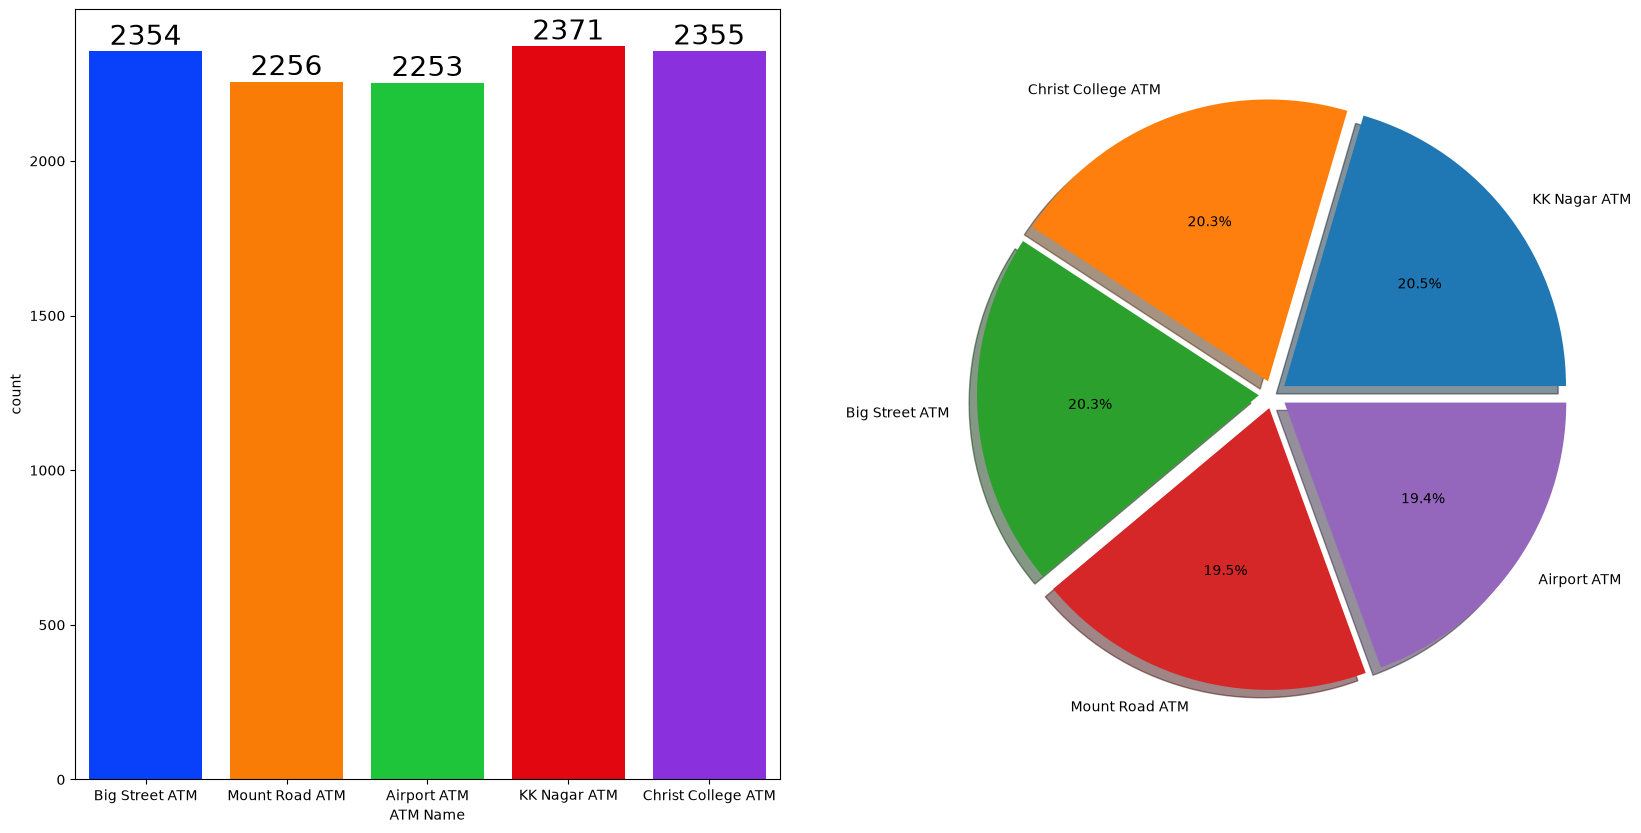

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot visualization
f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(x=df['ATM Name'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
    
plt.pie(x=df['ATM Name'].value_counts(), labels=df['ATM Name'].value_counts().index, 
        explode=[0.05]*len(df['ATM Name'].unique()), autopct='%1.1f%%', shadow=True)
plt.show()


#### Insights 
- The dataset features a highly balanced distribution of records across all five distinct physical locations.
- Each individual ATM contains between 2,253 and 2,371 logged operational days, ensuring completely uniform data collection for tracking.

#### 4.2 BIVARIATE ANALYSIS (Does location have an impact on average cash payouts?)

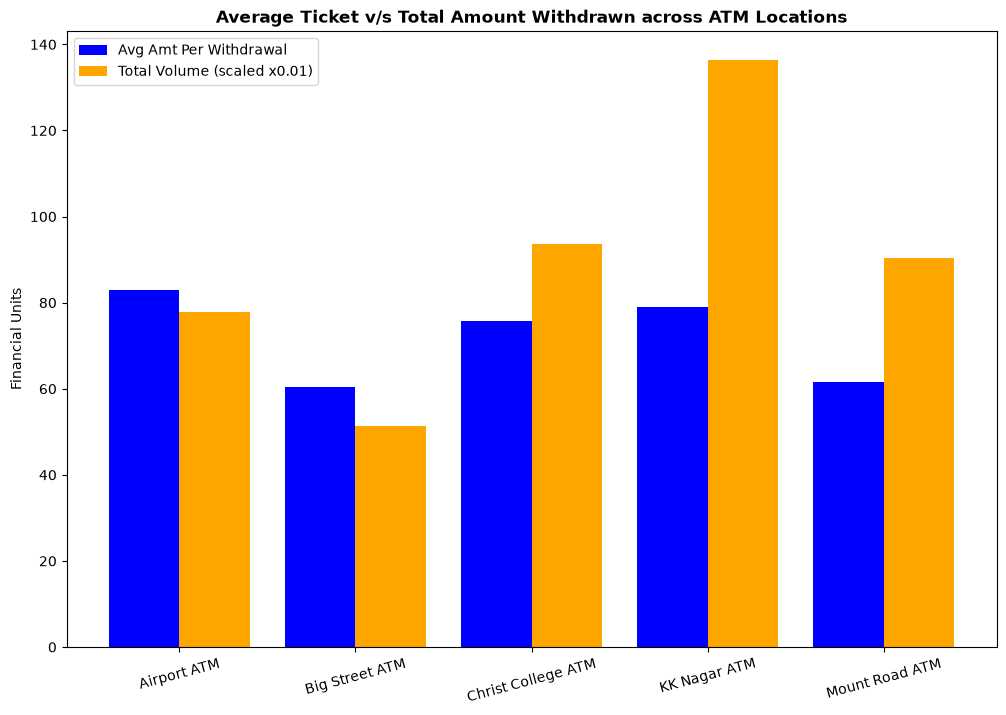

In [18]:
plt.figure(figsize=(12, 8))
# Calculate averages per location
atm_group = df.groupby('ATM Name')[['Avg Amt Per Withdrawal', 'Total amount Withdrawn']].mean()

X = atm_group.index
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, atm_group['Avg Amt Per Withdrawal'], 0.4, label='Avg Amt Per Withdrawal', color='blue')
plt.bar(X_axis + 0.2, atm_group['Total amount Withdrawn']/100, 0.4, label='Total Volume (scaled x0.01)', color='orange')
  
plt.xticks(X_axis, X, rotation=15)
plt.ylabel("Financial Units")
plt.title("Average Ticket v/s Total Amount Withdrawn across ATM Locations", fontweight='bold')
plt.legend()
plt.show()




#### insights 
- On average, the Airport ATM records the highest transaction ticket size at 82.96 units per individual cash withdrawal.
- KK Nagar ATM generates the highest daily total volume at 13,628.97 units, while Big Street ATM trails with the lowest daily total volume at 5,125.59 units.

####  WEEKDAY COLUMN UNIVARIATE ANALYSIS (How is day-of-week distribution grouped?)

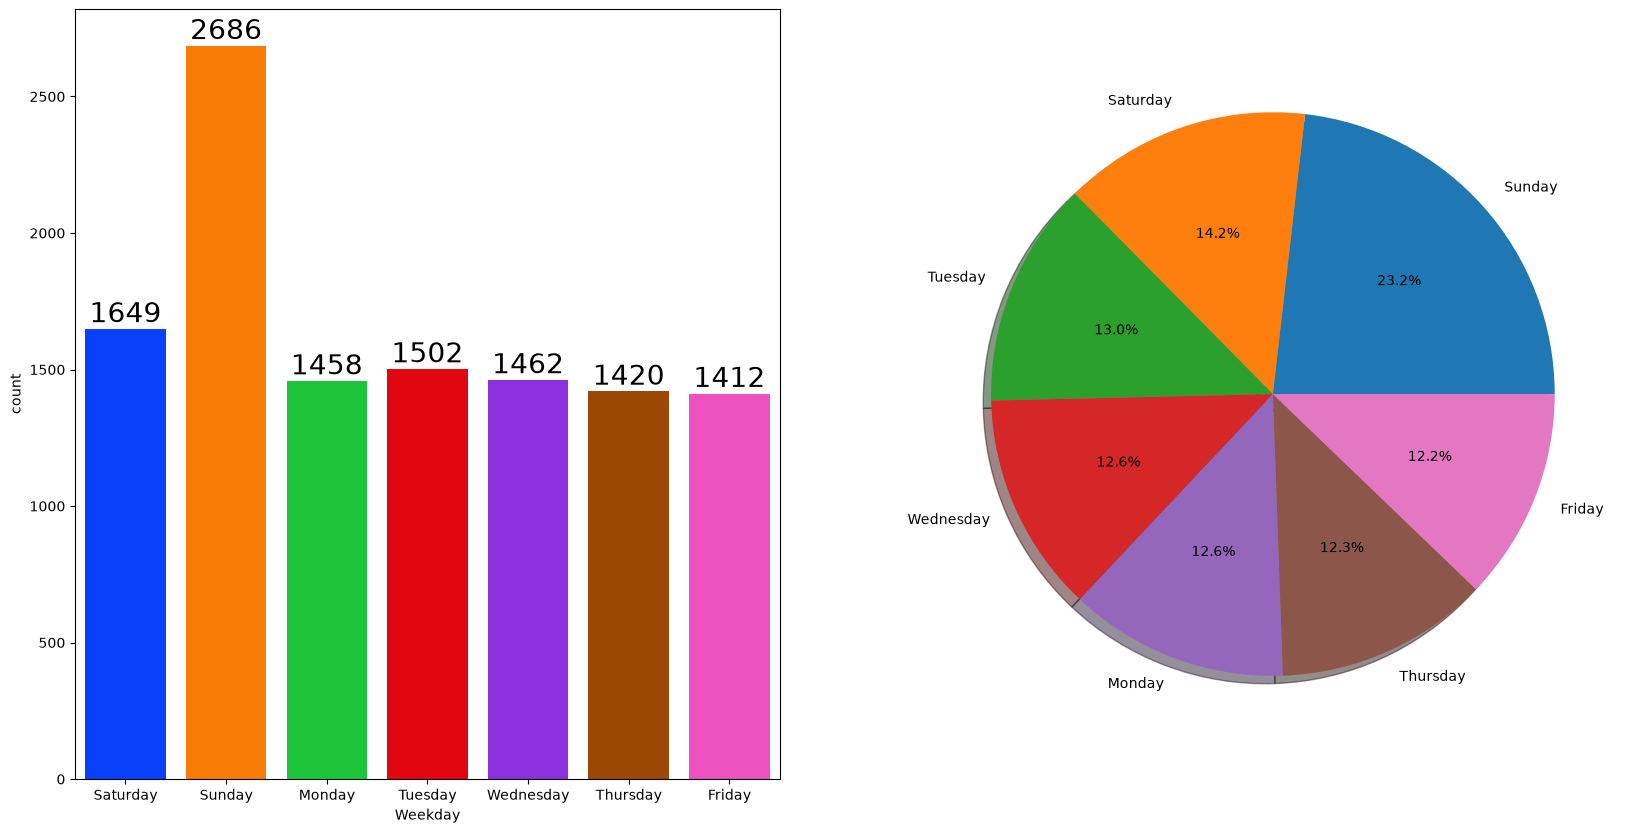

In [19]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(x=df['Weekday'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
    
plt.pie(x=df['Weekday'].value_counts(), labels=df['Weekday'].value_counts().index, autopct='%1.1f%%', shadow=True)
plt.show()   




#### insights 
- Sunday is the most heavily logged day in the dataset with 2,686 records, showing a significant concentration of transaction logging over the weekend.
- The remaining days from Monday through Friday maintain a highly stable and balanced tracking baseline, with each weekday capturing roughly 1,412 to 1,502 operational entries.

#### BIVARIATE ANALYSIS (Does weekday influence distinct card segment traffic?)

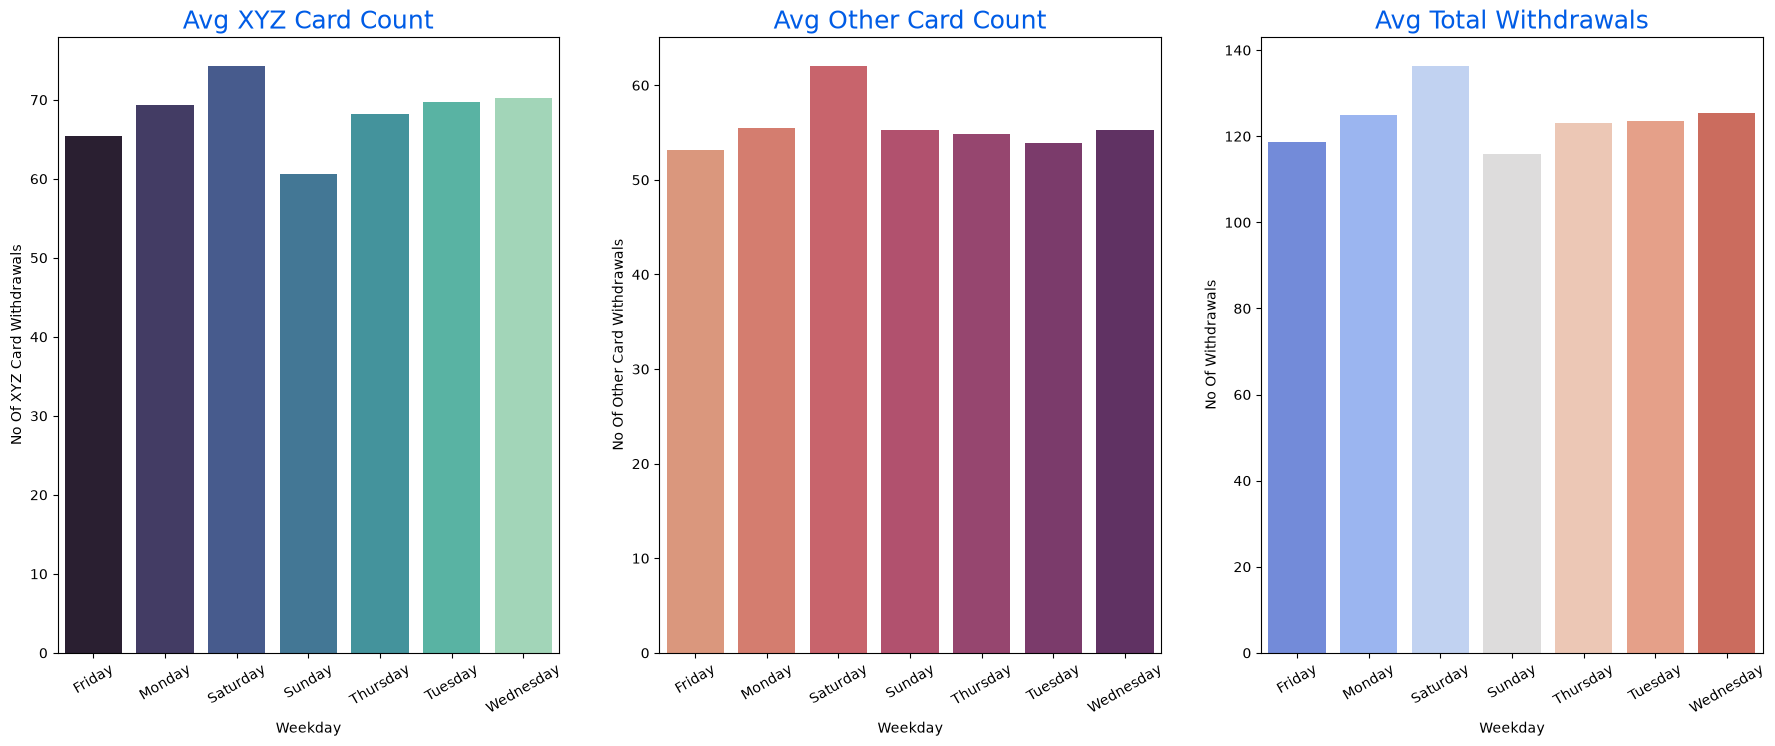

In [20]:
weekday_data = df.groupby('Weekday')[['No Of XYZ Card Withdrawals', 'No Of Other Card Withdrawals', 'No Of Withdrawals']].mean()

f, ax = plt.subplots(1, 3, figsize=(22, 8))
sns.barplot(x=weekday_data.index, y=weekday_data['No Of XYZ Card Withdrawals'], palette='mako', ax=ax[0])
ax[0].set_title('Avg XYZ Card Count', color='#005ce6', size=18)
ax[0].tick_params(axis='x', rotation=30)

sns.barplot(x=weekday_data.index, y=weekday_data['No Of Other Card Withdrawals'], palette='flare', ax=ax[1])
ax[1].set_title('Avg Other Card Count', color='#005ce6', size=18)
ax[1].tick_params(axis='x', rotation=30)

sns.barplot(x=weekday_data.index, y=weekday_data['No Of Withdrawals'], palette='coolwarm', ax=ax[2])
ax[2].set_title('Avg Total Withdrawals', color='#005ce6', size=18)
ax[2].tick_params(axis='x', rotation=30)
plt.show()

#### insights 
- Saturday experiences the highest average customer volume across all metrics, peaking at an average of 136.27 total daily withdrawals.
- Sunday shows a unique operational trend where own-bank XYZ card transactions drop to their lowest weekly average (60.67), while external "Other Cards" remain highly consistent with mid-week levels.

FESTIVAL RELIGION COLUMN

UNIVARIATE ANALYSIS (What is the distribution profile of festival classifications?)

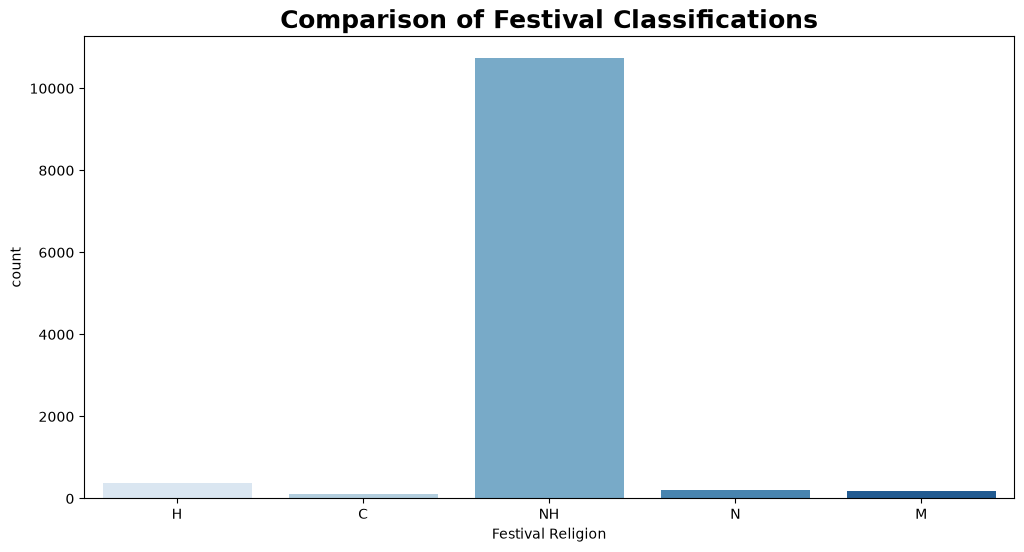

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Festival Religion'], palette='Blues')
plt.title('Comparison of Festival Classifications', fontweight='bold', fontsize=18)
plt.show()



#### insights 
- Standard non-festival days (NH) dominate the data with 10,727 entries, covering over 92% of the total calendar tracking history.
- Special religious events are relatively rare, with code H representing the most frequent festival exception at 367 instances.

#### BIVARIATE ANALYSIS (Do festival classifications shift the aggregate metrics baseline?)

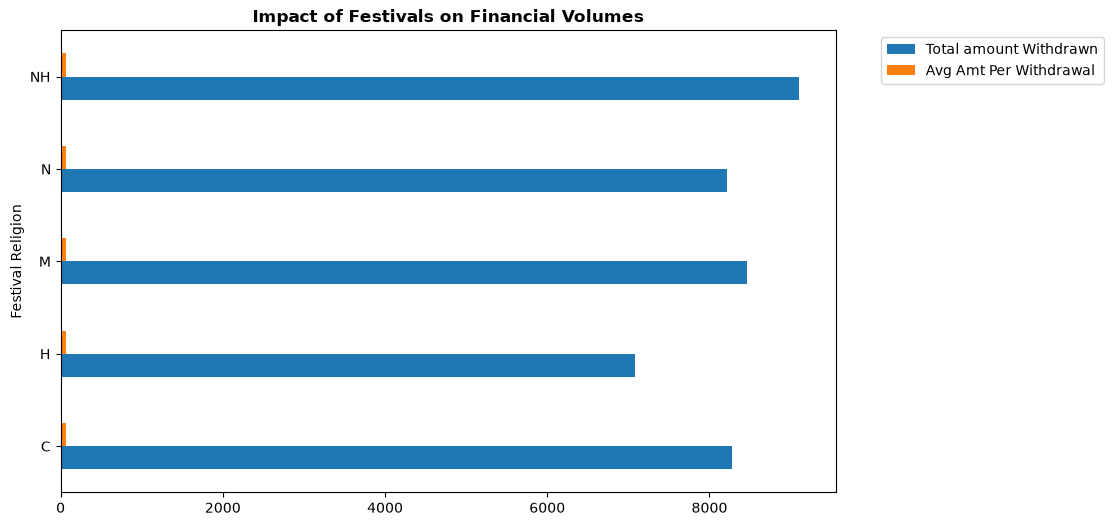

In [22]:
fest_group = df.groupby('Festival Religion')[['Total amount Withdrawn', 'Avg Amt Per Withdrawal']].mean()
fest_group.plot(kind='barh', figsize=(10, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.title("Impact of Festivals on Financial Volumes", fontweight='bold')
plt.show()



#### insights 
- Standard non-festival days (NH) generate the highest transactional velocity, leading both total volume (9,100.35) and average ticket size (72.18).
- Festival marker H exhibits the lowest overall operational baseline, dropping to an average daily total of 7,077.95 cash units dispensed.

####  WORKING DAY COLUMN

#### UNIVARIATE ANALYSIS (Which calendar environment is most common across data logs?)

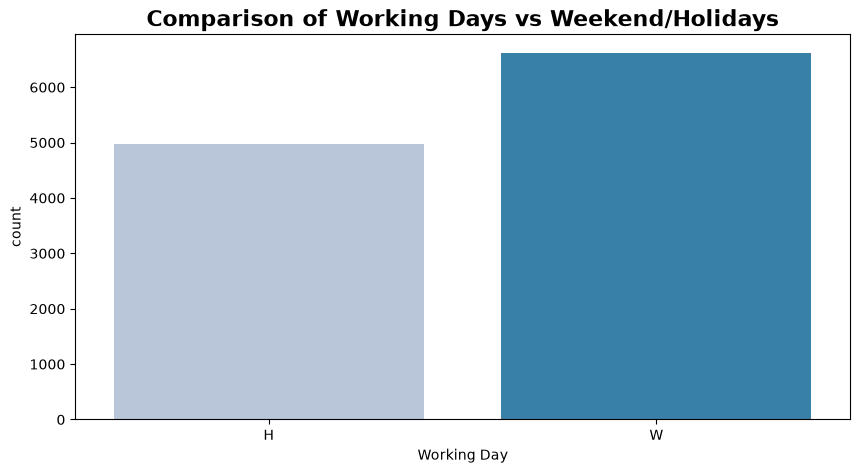

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Working Day'], palette='PuBu')
plt.title('Comparison of Working Days vs Weekend/Holidays', fontweight='bold', fontsize=16)
plt.show()



#### insights 
- Standard active scheduled workdays (W) make up the majority of the tracking data with 6,621 logged entries.
- Non-working days and weekend holidays (H) account for a substantial portion of the dataset at 4,968 entries, allowing for a strong comparative analysis between open and closed bank calendar dates.

#### BIVARIATE ANALYSIS (Does operational status affect concurrent surrounding cluster patterns?)

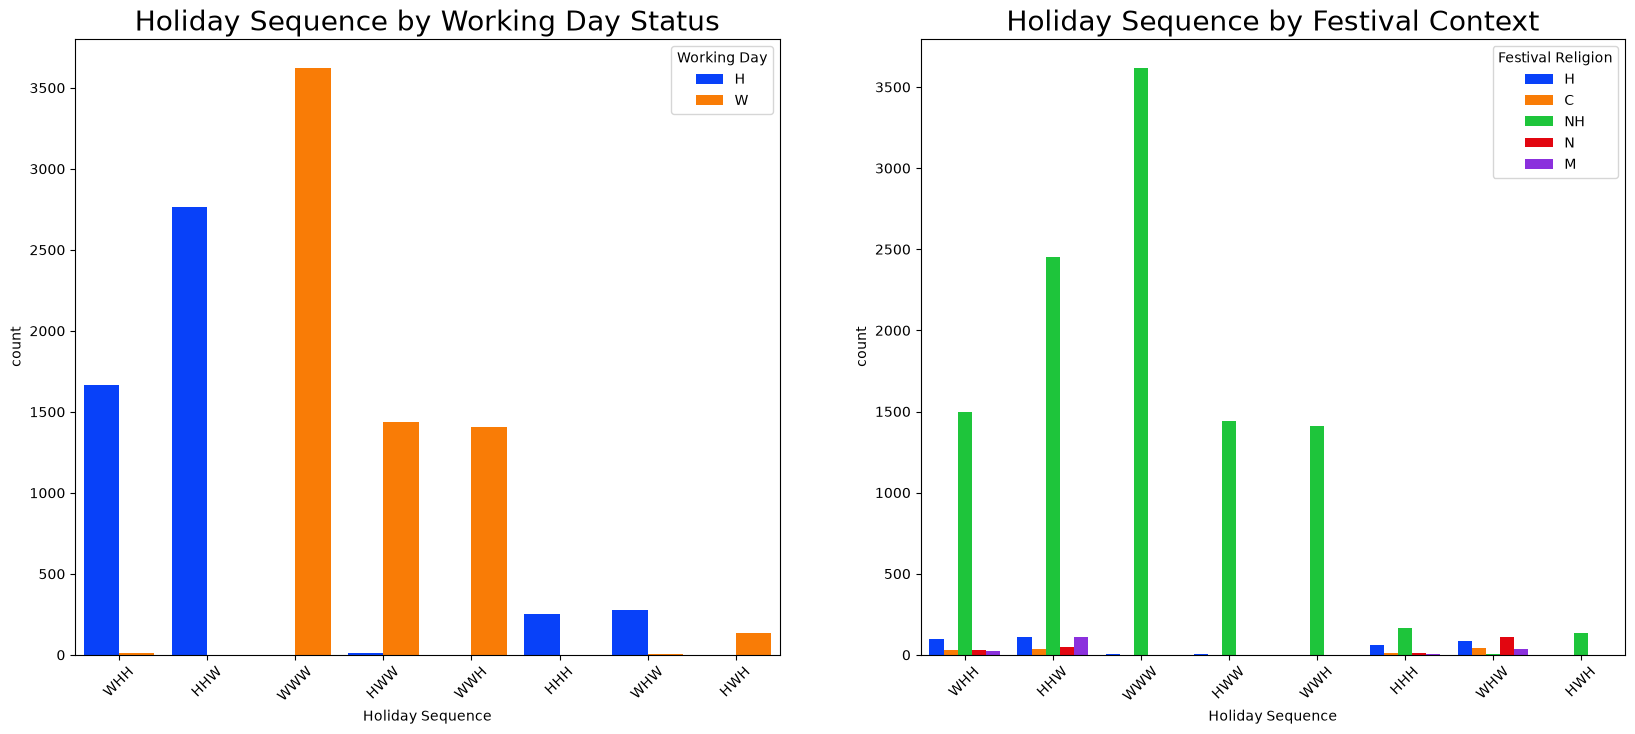

In [24]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.countplot(x=df['Holiday Sequence'], data=df, palette='bright', hue='Working Day', saturation=0.95, ax=ax[0])
ax[0].set_title('Holiday Sequence by Working Day Status', color='black', size=20)
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x=df['Holiday Sequence'], data=df, palette='bright', hue='Festival Religion', saturation=0.95, ax=ax[1])
ax[1].set_title('Holiday Sequence by Festival Context', color='black', size=20)
ax[1].tick_params(axis='x', rotation=45)
plt.show()



#### insights 
- Standard continuous work sequences (WWW) represent the largest operational block in the dataset with 3,621 clean working days.
- Holiday calendar blocks show a massive concentration in the HHW (2,763 entries) and WHH (1,664 entries) sequences, pinpointing the key weekend cluster boundaries for terminal cash planning.

####  BIVARIATE ANALYSIS (Is the surrounding holiday context a driver of terminal volume spikes?)

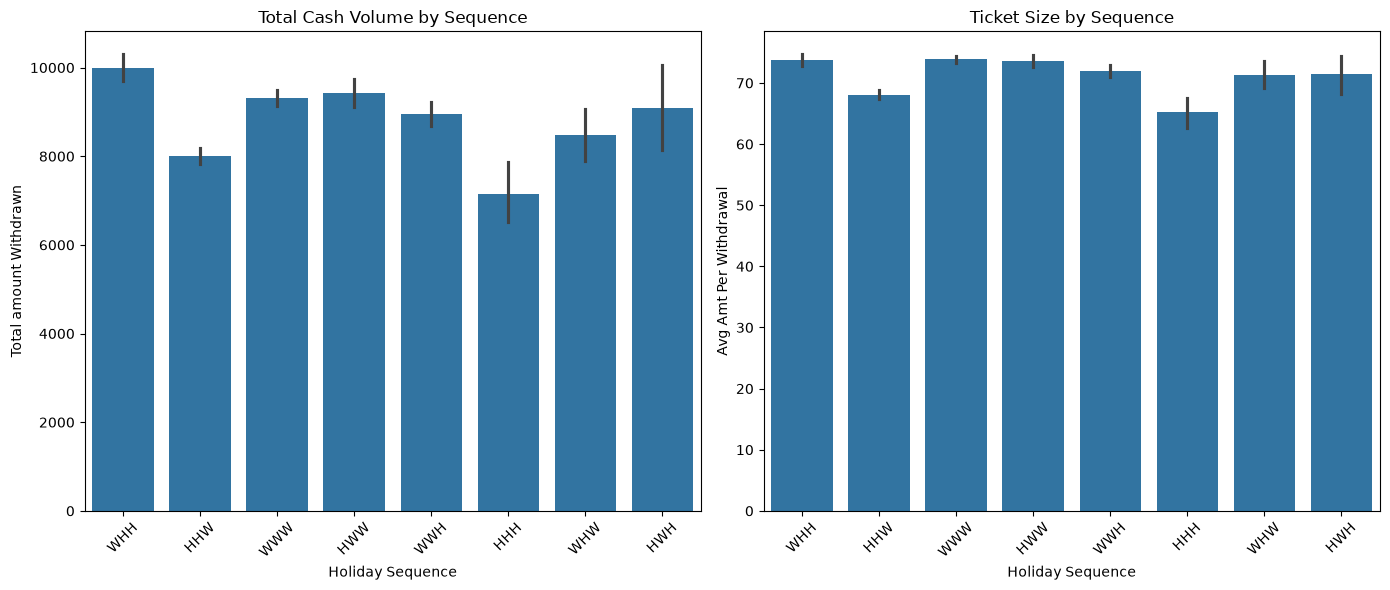

In [25]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=df['Holiday Sequence'], y=df['Total amount Withdrawn'])
plt.title('Total Cash Volume by Sequence')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=df['Holiday Sequence'], y=df['Avg Amt Per Withdrawal'])
plt.title('Ticket Size by Sequence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




#### CHECKING OUTLIERS

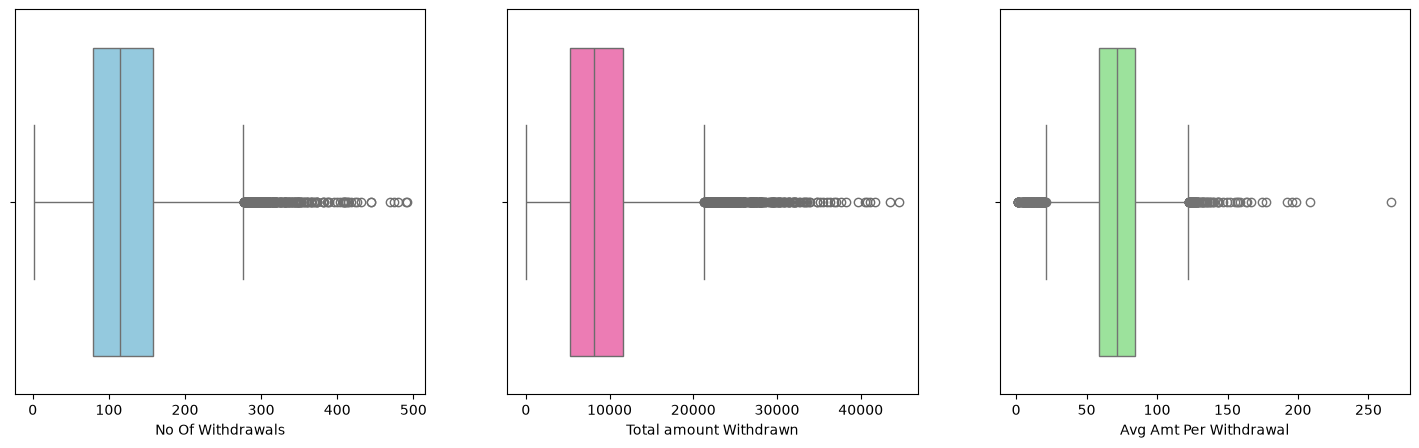

In [26]:
plt.subplots(1, 3, figsize=(18, 5))
plt.subplot(131)
sns.boxplot(x=df['No Of Withdrawals'], color='skyblue')
plt.subplot(132)
sns.boxplot(x=df['Total amount Withdrawn'], color='hotpink')
plt.subplot(133)
sns.boxplot(x=df['Avg Amt Per Withdrawal'], color='lightgreen')
plt.show()



#### insights 
- Extreme high-volume outliers are clear at the 99th percentile, where a single day can surge up to 316 withdrawals and over 26,918 cash units dispensed.
- The middle 50% of the dataset (the interquartile range from 25% to 75%) shows steady operations, with daily withdrawals hovering between 79 and 158 transactions, and ticket sizes staying between 59.05 and 84.34 units.

#### MULTIVARIATE ANALYSIS USING PAIRPLOT

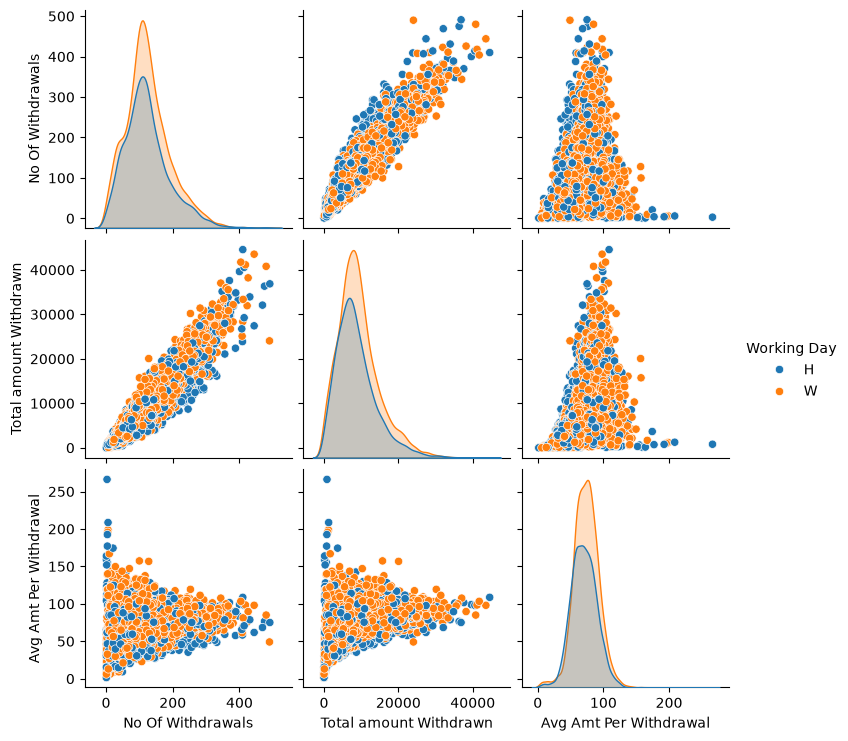

In [ ]:
# Focus pairplot on continuous performance variables
sns.pairplot(df[['No Of Withdrawals', 'Total amount Withdrawn', 'Avg Amt Per Withdrawal', 'Working Day']], hue='Working Day')
plt.show()



#### Conclusion 
- Key Performance Drivers: ATM performance is highly dependent on geographic ATM Location, Holiday Sequences, and Weekday placement.
- Location-Based Strategy: KK Nagar ATM requires maximum cash volume allocation due to its high daily throughput, while Airport ATM needs tracking for high-value ticket sizes.
- Holiday Clusters: The WHH (Work-Holiday-Holiday) calendar sequence generates the highest average financial demand, making it a critical window for proactive cash replenishment.
- Card Profile Baseline: Own-bank XYZ Cards maintain strong volume stability across the entire week, while competitor Other Cards hit unique velocity drops on weekend days.